In [1]:
# import general libraries
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
# import own classes (for stochastic simulation)
from agent_game_sim import QLearningAgent
from agent_game_sim import Game
from agent_game_sim import Simulation
# import own functions
from agent_game_sim import reward_matrix_for_two_player_MP # Matching Pennies
from agent_game_sim import reward_matrix_for_two_player_SH # Stag Hunt
from agent_game_sim import reward_matrix_for_two_player_BS # Bach or Stravinsky
from agent_game_sim import get_individual_matrices
from agent_game_sim import generate_q_values

# Set a fixed random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [2]:
# Deterministic Q-learning classes and functions 
class DeterministicAgent():
    def __init__(self, Q_values_initial, learning_rate, discount_factor, temperature):
        self.Q_values_initial = Q_values_initial
        self.Q_values = Q_values_initial
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.temperature = temperature
        self.Q_values_history = []
        self.prob_vector_history = []

    def get_prob_vector(self):
        return np.exp(self.Q_values / self.temperature) / np.sum(np.exp(self.Q_values / self.temperature))
    
    def update_history(self):
        self.Q_values_history.append(self.Q_values)
        self.prob_vector_history.append(self.get_prob_vector())

    def reset(self):
        self.Q_values = self.Q_values_initial

def deterministic_QL_step(agents, reward_matrices):
    '''Deterministic Q-learning step for a 2x2 repeated normal-form game for two agents'''
    for agent in agents:
        agent.update_history()

    agent_1, agent_2 = agents
    prob_vector_agent_1 = agent_1.get_prob_vector()
    prob_vector_agent_2 = agent_2.get_prob_vector()
    reward_matrix_A, reward_matrix_B = reward_matrices
    
    Q_vector_new_1 = agent_1.Q_values + agent_1.learning_rate * prob_vector_agent_1 * (reward_matrix_A @ prob_vector_agent_2 + agent_1.discount_factor * np.max(agent_1.Q_values) - agent_1.Q_values)
    Q_vector_new_2 = agent_2.Q_values + agent_2.learning_rate * prob_vector_agent_2 * (prob_vector_agent_1 @ reward_matrix_B + agent_2.discount_factor * np.max(agent_2.Q_values) - agent_2.Q_values)

    agent_1.Q_values = Q_vector_new_1
    agent_2.Q_values = Q_vector_new_2

# Stochastic Q-learning simulation function 
def run_stochastic_simulation(reward_function, num_time_steps, base_value, num_runs,
                               learning_rate, discount_factor, temperature,
                               initial_probability_pairs, split_groups=True):
    """
    Run stochastic Q-learning simulation and return grouped trajectories.
    """
    num_players = 2
    action_space = np.array([0, 1], dtype=float)
    use_prefactor = False
    agent_pair = [QLearningAgent, QLearningAgent]
    selection_method = "Boltzmann"
    
    trajectories_group_C = []
    trajectories_group_C_size = []
    trajectories_group_D = []
    trajectories_group_D_size = []
    
    for initial_probability_pair in initial_probability_pairs:
        initial_Q_tables = [generate_q_values(prob, temperature, base_value) for prob in initial_probability_pair]
        initial_Q_tables = [np.expand_dims(q_table, axis=0) for q_table in initial_Q_tables]
        
        agents = [agent_pair[i](player_id=i,
                        action_space=action_space,
                        num_players=num_players,
                        discount_factor=discount_factor,
                        selection_method=selection_method,
                        reward_func=reward_function,
                        q_table=initial_Q_tables[i],
                        temperature=temperature,
                        learning_rate=learning_rate,
                        use_prefactor=use_prefactor)
                        for i in range(num_players)]
        
        game = Game(agents=agents)
        simulation = Simulation()
        
        probabilities_runs_agents_group_C = []
        probabilities_runs_agents_group_D = []
        
        for run in range(num_runs):
            simulation.run(game, agents, num_time_steps)
            probabilities_agents = []
            for agent in agents:
                prob_first_action = np.array([agent.get_action_probabilities(q_table) 
                                              for q_table in agent.q_table_history[:]])[:, 0, 0]
                probabilities_agents.append(prob_first_action)
            
            if split_groups:
                last_probability_pair = np.array([probabilities_agents[0][-1], probabilities_agents[1][-1]])
                if last_probability_pair[1] > (1 - last_probability_pair[0]):
                    probabilities_runs_agents_group_C.append(probabilities_agents)
                else:
                    probabilities_runs_agents_group_D.append(probabilities_agents)
            else:
                probabilities_runs_agents_group_C.append(probabilities_agents)
        
        if len(probabilities_runs_agents_group_C) > 0:
            probabilities_group_C = np.mean(probabilities_runs_agents_group_C, axis=0)
        else:
            probabilities_group_C = None
        if len(probabilities_runs_agents_group_D) > 0:
            probabilities_group_D = np.mean(probabilities_runs_agents_group_D, axis=0)
        else:
            probabilities_group_D = None
        
        trajectories_group_C.append(probabilities_group_C)
        trajectories_group_D.append(probabilities_group_D)
        trajectories_group_C_size.append(len(probabilities_runs_agents_group_C) / num_runs)
        trajectories_group_D_size.append(len(probabilities_runs_agents_group_D) / num_runs)
    
    return trajectories_group_C, trajectories_group_D, trajectories_group_C_size, trajectories_group_D_size

In [3]:
# Plotting settings
directory_for_figures = 'PaperFigures'
if not os.path.exists(directory_for_figures):
    os.makedirs(directory_for_figures)
dpi = 300
SAVE_FIGURES = True

# Game parameter arrays
reward_function_array = [reward_matrix_for_two_player_MP, reward_matrix_for_two_player_SH, reward_matrix_for_two_player_BS]
game_title_short = ['MP', 'SH', 'BS']
game_title = ['Matching Pennies', 'Stag Hunt', 'Bach or Stravinsky']
first_action_title = ['H', 'S', 'B']
individual_reward_matrices_array = [get_individual_matrices(reward_function) for reward_function in reward_function_array]

# Simulation parameters
initial_probability_pairs = [(0.1, 0.9), (0.5, 0.9), (0.9, 0.9),
                             (0.1, 0.5), (0.5, 0.5), (0.9, 0.5),
                             (0.1, 0.1), (0.5, 0.1), (0.9, 0.1)]

# Learning parameters
learning_rate = 0.01
discount_factor = 0.5
temperature = 1
num_runs = 5  # for stochastic simulation

# Time steps and base values per game
num_time_steps_array = [int(2e3), int(3e4), int(4e4)]
base_value_min_array = np.array([np.min(m) for m in individual_reward_matrices_array]) * 1/(1-discount_factor)
base_value_max_array = np.array([np.max(m) for m in individual_reward_matrices_array]) * 1/(1-discount_factor)

# Whether to split into groups for each game (False for MP which has unique equilibrium)
split_groups_array = [False, True, True]  # MP: no split, SH: split, BS: split

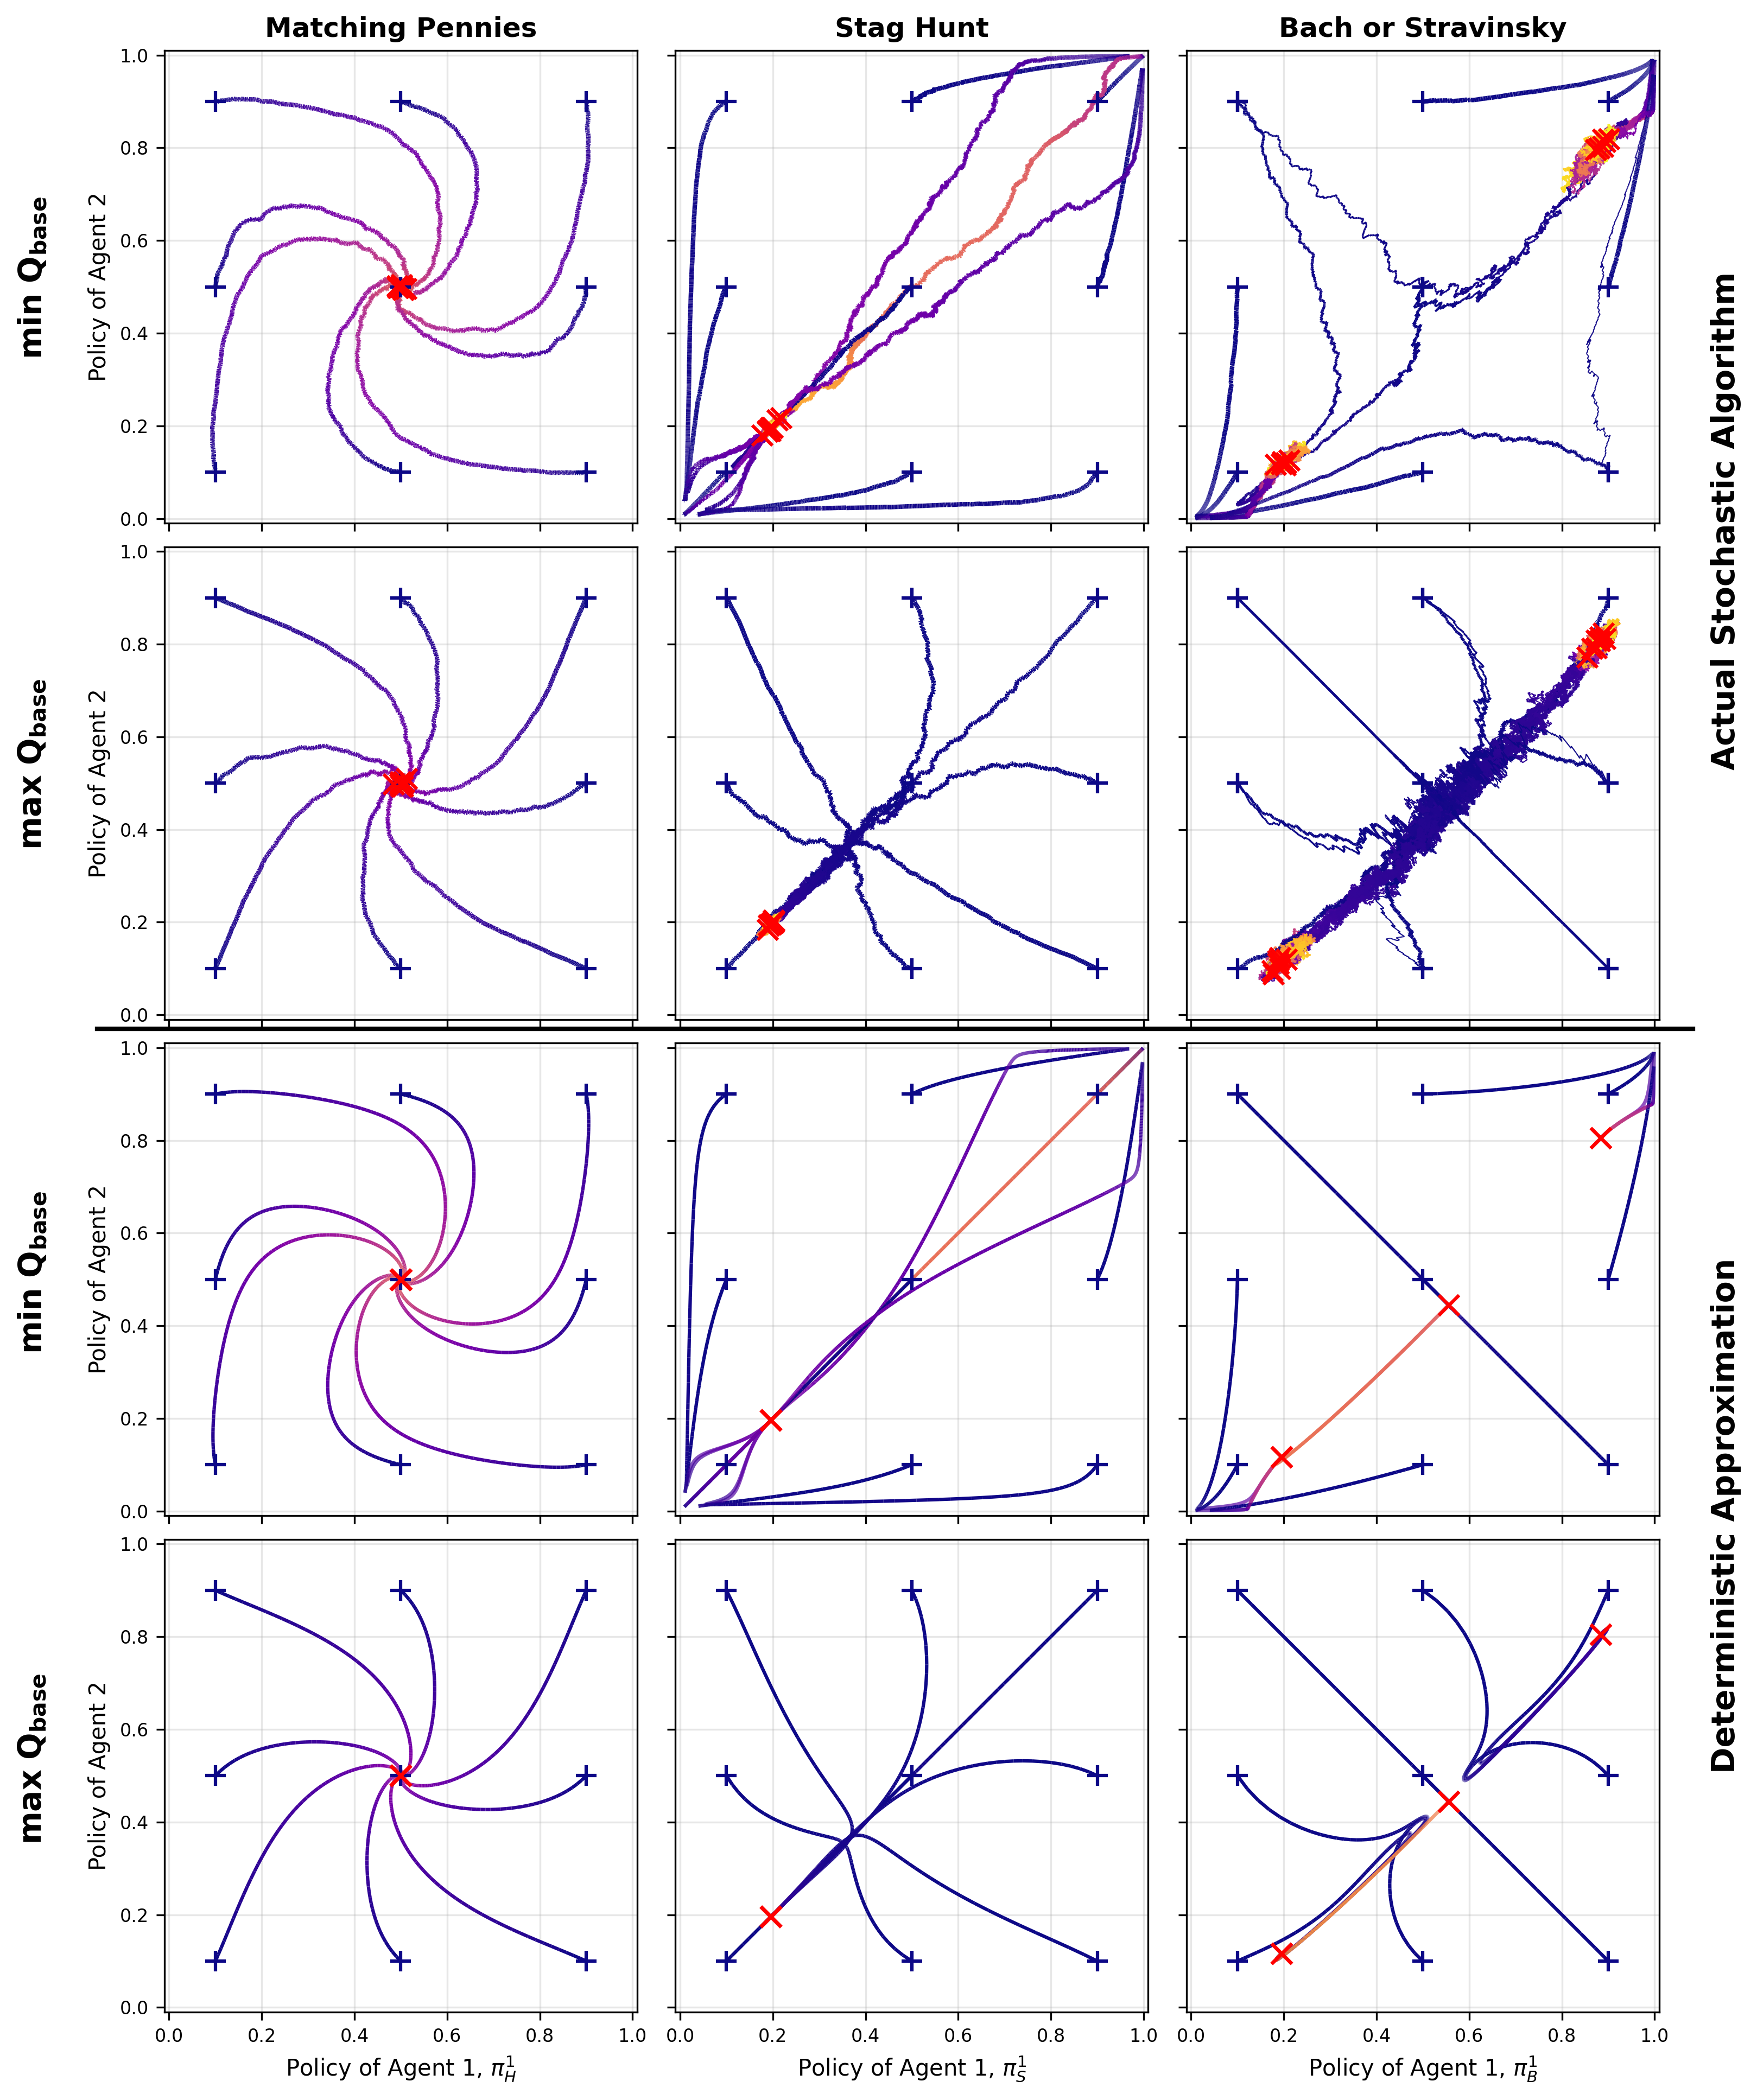

In [ ]:
# Create combined 4x3 grid figure with shared axes within deterministic and stochastic sections
fig, axes = plt.subplots(4, 3, figsize=(10, 13), dpi=dpi)

marker_size = 80
color_start_scatter = plt.cm.plasma(0.0)
color_end_scatter = 'red'
n_subsample = 10

row_configs = [
    (True, base_value_min_array),
    (True, base_value_max_array),
    (False, base_value_min_array),
    (False, base_value_max_array),
]

for row_idx, (is_stochastic, base_value_array) in enumerate(row_configs):
    for col_idx in range(len(game_title_short)): 
        ax = axes[row_idx, col_idx]
        
        base_value = base_value_array[col_idx]
        num_time_steps = num_time_steps_array[col_idx]
        
        if is_stochastic:
            # ===== STOCHASTIC SIMULATION =====
            reward_function = reward_function_array[col_idx]
            split_groups = split_groups_array[col_idx]
            
            trajectories_group_C, trajectories_group_D, trajectories_group_C_size, trajectories_group_D_size = \
                run_stochastic_simulation(reward_function, num_time_steps, base_value, num_runs,
                                           learning_rate, discount_factor, temperature,
                                           initial_probability_pairs, split_groups=split_groups)
            
            for g, (group, group_sizes) in enumerate([(trajectories_group_C, trajectories_group_C_size),
                                                       (trajectories_group_D, trajectories_group_D_size)]):
                for i, trajectory in enumerate(group):
                    if trajectory is not None:
                        prob_first_action_list = np.array([trajectory[0], trajectory[1]]).T
                        
                        lines = [[prob_first_action_list[j], prob_first_action_list[j+1]] 
                                 for j in range(len(prob_first_action_list)-1)]
                        size = 2 * group_sizes[i]
                        lc = LineCollection(lines, cmap='plasma', linewidths=max(size, 0.5), alpha=1)
                        lc.set_array(np.linspace(0, 1, len(prob_first_action_list)))
                        ax.add_collection(lc)
                        
                        ax.scatter(prob_first_action_list[0, 0], prob_first_action_list[0, 1], marker='+',
                                    color=color_start_scatter, zorder=10, s=marker_size)
                        ax.scatter(prob_first_action_list[-1, 0], prob_first_action_list[-1, 1], marker='x',
                                    color=color_end_scatter, zorder=10, s=marker_size)
        else:
            # ===== DETERMINISTIC SIMULATION =====
            individual_reward_matrices = individual_reward_matrices_array[col_idx]
            
            for initial_probability_pair in initial_probability_pairs:
                Q_values_initial_list = [generate_q_values(probability, temperature, base_value) 
                                          for probability in initial_probability_pair]
                agents = [DeterministicAgent(Q_values_initial, learning_rate, discount_factor, temperature) 
                          for Q_values_initial in Q_values_initial_list]
                
                for time_step in range(num_time_steps):
                    deterministic_QL_step(agents, individual_reward_matrices)
                
                prob_first_action_of_agent_1_list = [vector[0] for vector in agents[0].prob_vector_history[::n_subsample]]
                prob_first_action_of_agent_2_list = [vector[0] for vector in agents[1].prob_vector_history[::n_subsample]]
                prob_first_action_list = np.array([prob_first_action_of_agent_1_list, prob_first_action_of_agent_2_list]).T
                
                lines = [[prob_first_action_list[j], prob_first_action_list[j+1]] for j in range(len(prob_first_action_list)-1)]
                lc = LineCollection(lines, cmap='plasma', linewidths=1.5, alpha=1)
                lc.set_array(np.linspace(0, 1, len(prob_first_action_list)))
                ax.add_collection(lc)
                
                ax.scatter(prob_first_action_list[0, 0], prob_first_action_list[0, 1], marker='+',
                            color=color_start_scatter, zorder=10, s=marker_size)
                ax.scatter(prob_first_action_list[-1, 0], prob_first_action_list[-1, 1], marker='x',
                            color=color_end_scatter, zorder=10, s=marker_size)
        
        # Subplot cosmetics
        ax.set_xlim(-0.01, 1.01)
        ax.set_ylim(-0.01, 1.01)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True, alpha=0.3)
        ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        
        # Control tick label visibility for shared axes effect
        # X-tick labels: only on row 3 (bottom-most row)
        if row_idx == 3:
            ax.tick_params(axis='x', labelsize=8)
        else:
            ax.tick_params(axis='x', labelbottom=False, labelsize=8)
        
        # Y-tick labels: only on leftmost column (col 0)
        if col_idx == 0:
            ax.tick_params(axis='y', labelsize=8)
        else:
            ax.tick_params(axis='y', labelleft=False, labelsize=8)
        
        # Column titles (game names) - only on top row
        if row_idx == 0:
            ax.set_title(game_title[col_idx], fontsize=12, fontweight='bold')

        # Axis labels - only on leftmost column and bottom row
        if col_idx == 0:
            ax.set_ylabel(f'Policy of Agent 2', fontsize=10)

        if row_idx == 3:  # Bottom-most row only
            ax.set_xlabel(f'Policy of Agent 1, $\\pi^1_{{{first_action_title[col_idx]}}}$', fontsize=10)

# Add min/max Q_base labels on the far left for each row
fig.text(-0.02, 0.865, r'$\bf{min}$ $\bf{Q_{base}}$', va='center', ha='center', rotation=90, fontsize=14, transform=fig.transFigure)
fig.text(-0.02, 0.635, r'$\bf{max}$ $\bf{Q_{base}}$', va='center', ha='center', rotation=90, fontsize=14, transform=fig.transFigure)
fig.text(-0.02, 0.395, r'$\bf{min}$ $\bf{Q_{base}}$', va='center', ha='center', rotation=90, fontsize=14, transform=fig.transFigure)
fig.text(-0.02, 0.165, r'$\bf{max}$ $\bf{Q_{base}}$', va='center', ha='center', rotation=90, fontsize=14, transform=fig.transFigure)

# Add section labels on the left side
fig.text(1.02, 0.75, 'Actual Stochastic Algorithm', va='center', ha='center', fontsize=14, fontweight='bold', rotation=90, transform=fig.transFigure)
fig.text(1.02, 0.28, 'Deterministic Approximation', va='center', ha='center', fontsize=14, fontweight='bold', rotation=90, transform=fig.transFigure)

# Add a horizontal separator line between stochastic and deterministic sections
line_y = 0.51
fig.add_artist(plt.Line2D([0.02, 1], [line_y, line_y], transform=fig.transFigure, 
                          color='black', linewidth=2, linestyle='-'))

plt.tight_layout()
# Tighter spacing within sections, but maintain space around separator
plt.subplots_adjust(hspace=0.05, wspace=0.05)

if SAVE_FIGURES:
    filename = f'Fig6_{discount_factor}_temp_{temperature}_learningRate_{learning_rate}_numRuns_{num_runs}.jpg'
    plt.savefig(os.path.join(directory_for_figures, filename), dpi=dpi, bbox_inches='tight')

plt.show()